# 85 — Is the news new, or already known?

**Selected RQ (Gate F1).** Does negative-news share add predictive information for
next-session abnormal returns beyond mean continuous sentiment and news volume?

**What this notebook adds.** Every aggregate in that question is computed over
*all* stories on a firm-day, including near-verbatim restatements of headlines the
same firm already produced. If the market prices information rather than column
inches, the signal should sit in the new stories and be absent from the already-
known ones. This notebook separates the two legs and tests that directly.

**Frozen before execution** in
`frozen_specs/novelty_conditioned_information_v1_20260814.json`:

* "Already known" = an exact normalized-headline repeat, or token Jaccard overlap
  ≥ 0.50, against a **strictly earlier** same-firm session in a 30-day window.
  The 0.50 operative threshold was picked return-blind from a count screen; 0.80
  leaves only 3.4% of firm-days mixed, and 0.30 starts absorbing boilerplate.
* Three primary tests, BH-corrected across the family at q = 0.05:
  **T1** mean sentiment new − already known; **T2** negative share new − already
  known; **T3** the already-known share itself, added to the frozen regressors.
* Development block only (`session_date <= 2019-12-31`). The evaluation block is
  not loaded. Notebook 75 already opened it once and is not touched here.

**The screen is uncalibrated.** Notebook 02's blinded 180-story audit still has no
human labels, so "already known" means "near-verbatim repeat", not "the market
knew". A paraphrase that shares few tokens is scored as new.

In [1]:
from __future__ import annotations

import hashlib
import json
import sqlite3
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "final_experiments":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.conditional_aggregation import hac_mean_coefficient  # noqa: E402
from final_experiments.lib.evaluate import block_bootstrap_mean  # noqa: E402
from final_experiments.lib.novelty_conditioning import (  # noqa: E402
    PRIMARY_JACCARD_THRESHOLD,
    SENSITIVITY_JACCARD_THRESHOLDS,
    contrast_series,
    daily_rank_regression,
    firm_day_split_aggregates,
    recombination_error,
)
from final_experiments.lib.panel import DEFAULT_EVENTS_DB  # noqa: E402
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    annotate_source,
    apply_house_style,
    zero_line,
)

apply_house_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

OUTPUT = ROOT / "final_experiments/outputs/85_fnspid_novelty_conditioned_information"
OUTPUT.mkdir(parents=True, exist_ok=True)
SPEC_PATH = ROOT / "final_experiments/frozen_specs/novelty_conditioned_information_v1_20260814.json"
NOVELTY_PATH = ROOT / "final_experiments/outputs/02_filters_and_distribution/story_novelty.parquet"
PANEL_PATH = ROOT / "final_experiments/outputs/03_aggregation/firm_day_aggregators.parquet"

DEVELOPMENT_END = pd.Timestamp("2019-12-31")
OUTCOME = "ar_open_h1"
MIN_NAMES = 10
HAC_LAGS = 5
BOOTSTRAP_BLOCK = 20
BOOTSTRAP_REPLICATIONS = 9_999
BOOTSTRAP_SEED = 20_260_814

SPLIT_REGRESSORS = ["mean_new", "mean_known", "negshare_new", "negshare_known", "log1p_n"]
KNOWN_SHARE_REGRESSORS = ["mean_continuous", "negative_share", "known_share", "log1p_n"]


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


print(f"repo:   {ROOT}")
print(f"output: {OUTPUT.relative_to(ROOT)}")

repo:   /Users/peterprendergast/Documents/Sentiment_Dissertation
output: final_experiments/outputs/85_fnspid_novelty_conditioned_information


## 1. Frozen specification and input identity

In [2]:
spec = json.loads(SPEC_PATH.read_text())
if spec["status"] != "frozen_before_notebook_85_result":
    raise ValueError("unexpected frozen-spec status")
if spec["experiment"]["evaluation_block_opened"]:
    raise ValueError("spec claims the evaluation block is open")

input_audit = pd.DataFrame(
    [
        {
            "input": name,
            "path": entry["path"],
            "expected_sha256": entry["sha256"],
            "actual_sha256": sha256(ROOT / entry["path"]),
        }
        for name, entry in spec["inputs"].items()
    ]
)
input_audit["match"] = input_audit["expected_sha256"] == input_audit["actual_sha256"]
if not input_audit["match"].all():
    raise ValueError("input hash mismatch — the frozen spec does not describe these files")
input_audit.to_csv(OUTPUT / "input_audit.csv", index=False)
display(input_audit[["input", "path", "match"]])

display(
    Markdown(
        "**Primary threshold** {:.2f} · **sensitivity** {} · **family** {} tests, BH q=0.05".format(
            PRIMARY_JACCARD_THRESHOLD,
            ", ".join(f"{value:.2f}" for value in SENSITIVITY_JACCARD_THRESHOLDS),
            len(spec["primary_family"]["tests"]),
        )
    )
)

,input,path,match
0,fnspid_story_novelty,final_experiments/outputs/02_filters_and_distr...,True
1,fnspid_firm_day_aggregators,final_experiments/outputs/03_aggregation/firm_...,True
2,fnspid_finbert_checkpoint,reports/loop_moment2_finbert_20260719/finbert_...,True


**Primary threshold** 0.50 · **sensitivity** 0.40, 0.60, 0.80 · **family** 3 tests, BH q=0.05

## 2. Load the development story population

Per-story FinBERT scores join the repetition screen on `event_key`. Headline text
is never selected. Everything after 2019-12-31 is dropped before any outcome is
attached, so the evaluation block is not read.

In [3]:
panel = pd.read_parquet(PANEL_PATH)
panel["session_date"] = pd.to_datetime(panel["session_date"]).dt.normalize()
development = panel.loc[panel["session_date"] <= DEVELOPMENT_END].copy()
if development["split"].nunique() != 1 or development["split"].iloc[0] != "development":
    raise RuntimeError("date filter and stored split label disagree")

novelty = pd.read_parquet(
    NOVELTY_PATH,
    columns=[
        "event_key",
        "symbol",
        "session_date",
        "is_market_recap",
        "headline_norm_sha256",
        "exact_repeat_in_window",
        "max_jaccard_in_window",
        "days_since_prior_story",
    ],
)
novelty["session_date"] = pd.to_datetime(novelty["session_date"]).dt.normalize()
novelty = novelty.loc[novelty["session_date"] <= DEVELOPMENT_END]

connection = sqlite3.connect(f"file:{DEFAULT_EVENTS_DB}?mode=ro", uri=True)
try:
    scores = pd.read_sql_query(
        "SELECT event_key, finbert_score, p_negative, p_neutral, p_positive FROM events",
        connection,
    )
finally:
    connection.close()

stories = novelty.merge(scores, on="event_key", how="inner", validate="one_to_one")
stories = stories.dropna(subset=["finbert_score", "p_negative", "p_neutral", "p_positive"])

load_audit = pd.DataFrame(
    [
        {"stage": "development firm-days in panel", "rows": int(len(development))},
        {"stage": "development stories in novelty screen", "rows": int(len(novelty))},
        {"stage": "stories with a joined FinBERT score", "rows": int(len(stories))},
        {"stage": "distinct symbols", "rows": int(stories["symbol"].nunique())},
        {"stage": "distinct sessions", "rows": int(stories["session_date"].nunique())},
    ]
)
load_audit.to_csv(OUTPUT / "load_audit.csv", index=False)
display(load_audit)

,stage,rows
0,development firm-days in panel,512153
1,development stories in novelty screen,1183961
2,stories with a joined FinBERT score,1183961
3,distinct symbols,570
4,distinct sessions,2264


## 3. Measurement: how much of the flow is already known?

The first half of the question is descriptive and needs no return. The screen is
conservative by construction, so read these as a lower bound on repetition.

In [4]:
measurement_rows: list[dict[str, Any]] = []
for threshold in (PRIMARY_JACCARD_THRESHOLD, *SENSITIVITY_JACCARD_THRESHOLDS):
    exact = stories["exact_repeat_in_window"].to_numpy(dtype=bool)
    known = exact | (stories["max_jaccard_in_window"].to_numpy(dtype=float) >= threshold)
    measurement_rows.append(
        {
            "jaccard_threshold": threshold,
            "stories": int(len(stories)),
            "already_known": int(known.sum()),
            "already_known_share": float(known.mean()),
            "exact_repeat_share": float(exact.mean()),
        }
    )
measurement = pd.DataFrame(measurement_rows).sort_values("jaccard_threshold").reset_index(drop=True)
measurement.to_csv(OUTPUT / "already_known_share_by_threshold.csv", index=False)
display(measurement)

,jaccard_threshold,stories,already_known,already_known_share,exact_repeat_share
0,0.400000,1183961,167623,0.141578,0.013376
1,0.500000,1183961,111963,0.094566,0.013376
2,0.600000,1183961,69252,0.058492,0.013376
3,0.800000,1183961,30377,0.025657,0.013376


In [5]:
split_primary = firm_day_split_aggregates(stories, jaccard_threshold=PRIMARY_JACCARD_THRESHOLD)
reconciliation = split_primary.merge(
    development[["symbol", "session_date", "n", "mean_continuous", "negative_share"]].rename(
        columns={"n": "n_panel", "mean_continuous": "mean_panel", "negative_share": "negshare_panel"}
    ),
    on=["symbol", "session_date"],
    how="inner",
)
recombination = recombination_error(split_primary)
published_gap = pd.DataFrame(
    [
        {
            "check": "count vs published n",
            "max_abs_error": float((reconciliation["n"] - reconciliation["n_panel"]).abs().max()),
        },
        {
            "check": "mean_all vs published mean_continuous",
            "max_abs_error": float((reconciliation["mean_all"] - reconciliation["mean_panel"]).abs().max()),
        },
        {
            "check": "negshare_all vs published negative_share",
            "max_abs_error": float((reconciliation["negshare_all"] - reconciliation["negshare_panel"]).abs().max()),
        },
    ]
)
checks = pd.concat([recombination.rename(columns={"statistic": "check"}), published_gap], ignore_index=True)
checks.to_csv(OUTPUT / "reconciliation_checks.csv", index=False)
display(checks)
if checks["max_abs_error"].max() > 1e-9:
    raise RuntimeError("split aggregates do not reproduce the published firm-day aggregates")

,check,max_abs_error
0,mean_all,0.000000
1,negshare_all,0.000000
2,count vs published n,0.000000
3,mean_all vs published mean_continuous,0.000000
4,negshare_all vs published negative_share,0.000000


In [6]:
coverage = pd.DataFrame(
    [
        {
            "jaccard_threshold": threshold,
            "firm_days": int(len(frame)),
            "any_already_known": int((frame["n_known"] > 0).sum()),
            "mixed_days": int(frame["is_mixed_day"].sum()),
            "mixed_share": float(frame["is_mixed_day"].mean()),
            "median_n_mixed": float(frame.loc[frame["is_mixed_day"], "n"].median()),
            "median_n_all": float(frame["n"].median()),
        }
        for threshold, frame in (
            (threshold, firm_day_split_aggregates(stories, jaccard_threshold=threshold))
            for threshold in sorted({PRIMARY_JACCARD_THRESHOLD, *SENSITIVITY_JACCARD_THRESHOLDS})
        )
    ]
)
coverage.to_csv(OUTPUT / "mixed_day_coverage.csv", index=False)
display(coverage)
display(
    Markdown(
        "Mixed firm-days carry more stories than the panel median "
        f"({coverage.loc[coverage['jaccard_threshold'] == PRIMARY_JACCARD_THRESHOLD, 'median_n_mixed'].item():.0f} "
        f"vs {coverage.loc[coverage['jaccard_threshold'] == PRIMARY_JACCARD_THRESHOLD, 'median_n_all'].item():.0f}). "
        "The contrast is therefore identified on the busier end of the panel; this is disclosed, not corrected."
    )
)

,jaccard_threshold,firm_days,any_already_known,mixed_days,mixed_share,median_n_mixed,median_n_all
0,0.400000,512153,115542,72259,0.141089,3.000000,2.000000
1,0.500000,512153,82027,53367,0.104201,3.000000,2.000000
2,0.600000,512153,54700,36433,0.071137,3.000000,2.000000
3,0.800000,512153,25313,17268,0.033716,3.000000,2.000000


Mixed firm-days carry more stories than the panel median (3 vs 2). The contrast is therefore identified on the busier end of the panel; this is disclosed, not corrected.

In [7]:
by_year = (
    stories.assign(
        year=stories["session_date"].dt.year,
        already_known=stories["exact_repeat_in_window"].to_numpy(dtype=bool)
        | (stories["max_jaccard_in_window"].to_numpy(dtype=float) >= PRIMARY_JACCARD_THRESHOLD),
    )
    .groupby("year")
    .agg(
        stories=("already_known", "size"),
        already_known_share=("already_known", "mean"),
        market_recap_share=("is_market_recap", "mean"),
    )
    .reset_index()
)
by_year.to_csv(OUTPUT / "already_known_share_by_year.csv", index=False)

syndication = stories.groupby(["session_date", "headline_norm_sha256"])["symbol"].nunique()
syndication_summary = pd.DataFrame(
    [
        {
            "metric": "share of story hashes carried by more than one symbol on the same session",
            "value": float((syndication > 1).mean()),
        },
        {"metric": "mean symbols per same-session story hash", "value": float(syndication.mean())},
    ]
)
syndication_summary.to_csv(OUTPUT / "cross_firm_syndication.csv", index=False)
display(by_year)
display(syndication_summary)

,year,stories,already_known_share,market_recap_share
0,2011,65310,0.114638,0.064385
1,2012,89884,0.096803,0.067598
2,2013,92956,0.107223,0.090096
3,2014,103212,0.095871,0.140022
4,2015,139175,0.080187,0.096562
5,2016,151934,0.077395,0.086728
6,2017,154896,0.085296,0.088537
7,2018,198619,0.100942,0.121182
8,2019,187975,0.104977,0.098635


,metric,value
0,share of story hashes carried by more than one...,0.227072
1,mean symbols per same-session story hash,1.380043


findfont: Failed to find font weight medium, now using 400.


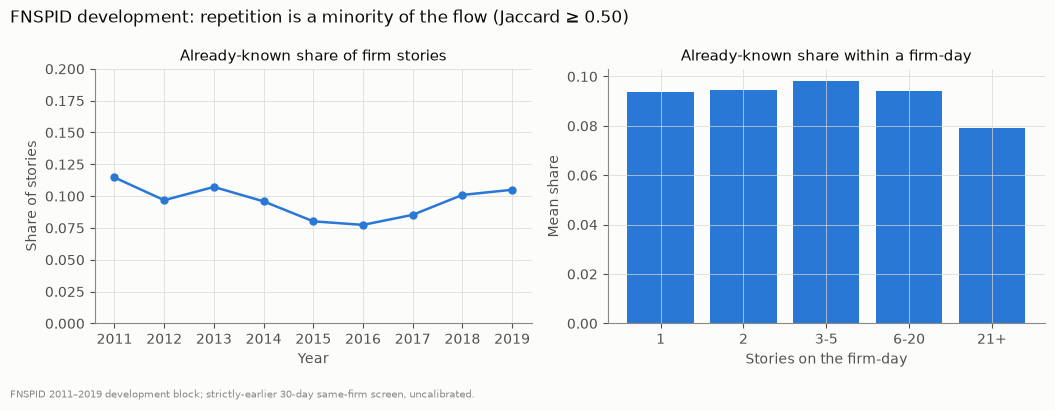

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

axes[0].plot(by_year["year"], by_year["already_known_share"], color=CATEGORICAL[0], marker="o", lw=1.8)
axes[0].set_title("Already-known share of firm stories")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Share of stories")
axes[0].set_ylim(0, max(0.2, by_year["already_known_share"].max() * 1.3))

n_bins = pd.cut(split_primary["n"], bins=[0, 1, 2, 5, 20, np.inf], labels=["1", "2", "3-5", "6-20", "21+"])
by_n = split_primary.groupby(n_bins, observed=True)["known_share"].mean()
axes[1].bar(by_n.index.astype(str), by_n.to_numpy(), color=CATEGORICAL[0])
axes[1].set_title("Already-known share within a firm-day")
axes[1].set_xlabel("Stories on the firm-day")
axes[1].set_ylabel("Mean share")

fig.suptitle(
    f"FNSPID development: repetition is a minority of the flow (Jaccard ≥ {PRIMARY_JACCARD_THRESHOLD:.2f})",
    ha="left",
    x=0.0,
)
annotate_source(fig, "FNSPID 2011–2019 development block; strictly-earlier 30-day same-firm screen, uncalibrated.")
fig.tight_layout()
fig.savefig(OUTPUT / "already_known_measurement.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Primary family

The outcome enters here for the first time. One execution of the three declared
tests; no specification is added after a coefficient is visible.

In [9]:
outcome_frame = development[["symbol", "session_date", OUTCOME, "mean_continuous", "negative_share"]]


def build_test_frame(threshold: float) -> pd.DataFrame:
    split = firm_day_split_aggregates(stories, jaccard_threshold=threshold)
    frame = split.merge(outcome_frame, on=["symbol", "session_date"], how="inner")
    frame["log1p_n"] = np.log1p(frame["n"].to_numpy(dtype=float))
    return frame


def run_family(threshold: float, *, label: str) -> tuple[pd.DataFrame, dict[str, pd.DataFrame], dict[str, Any]]:
    frame = build_test_frame(threshold)
    mixed = frame.loc[frame["is_mixed_day"]].copy()

    split_daily, split_audit = daily_rank_regression(
        mixed,
        date_col="session_date",
        outcome_col=OUTCOME,
        regressor_cols=SPLIT_REGRESSORS,
        min_names=MIN_NAMES,
    )
    split_daily = contrast_series(
        split_daily, minuend="beta_mean_new", subtrahend="beta_mean_known", name="contrast_mean"
    )
    split_daily = contrast_series(
        split_daily, minuend="beta_negshare_new", subtrahend="beta_negshare_known", name="contrast_negshare"
    )

    known_daily, known_audit = daily_rank_regression(
        frame,
        date_col="session_date",
        outcome_col=OUTCOME,
        regressor_cols=KNOWN_SHARE_REGRESSORS,
        min_names=MIN_NAMES,
    )

    rows = []
    for test_id, name, daily, column, direction in (
        ("T1", "mean: new − already known", split_daily, "contrast_mean", "positive"),
        ("T2", "negative share: new − already known", split_daily, "contrast_negshare", "negative"),
        ("T3", "already-known share beyond frozen regressors", known_daily, "beta_known_share", "none"),
    ):
        summary = hac_mean_coefficient(daily, coefficient_col=column, hac_lags=HAC_LAGS)
        boot = block_bootstrap_mean(
            daily[column].to_numpy(dtype=float),
            block_length=BOOTSTRAP_BLOCK,
            replications=BOOTSTRAP_REPLICATIONS,
            seed=BOOTSTRAP_SEED,
        )
        rows.append(
            {
                "test": test_id,
                "name": name,
                "threshold": threshold,
                "sample": label,
                "sessions": int(summary["n_clusters"]),
                "estimate": float(summary["estimate"]),
                "hac_ci_low": float(summary["ci_low"]),
                "hac_ci_high": float(summary["ci_high"]),
                "hac_p": float(summary["p_two_sided"]),
                "block_ci_low": float(boot["ci_low"]),
                "block_ci_high": float(boot["ci_high"]),
                "expected_direction": direction,
                "direction_matches": (
                    True
                    if direction == "none"
                    else (float(summary["estimate"]) > 0 if direction == "positive" else float(summary["estimate"]) < 0)
                ),
            }
        )

    audits = {
        "split_model": pd.DataFrame([split_audit]),
        "known_share_model": pd.DataFrame([known_audit]),
    }
    diagnostics = {
        "mixed_firm_days": int(len(mixed)),
        "all_firm_days": int(len(frame)),
        "split_median_condition_number": float(split_daily["condition_number"].median()),
        "known_median_condition_number": float(known_daily["condition_number"].median()),
        "mixed_rank_spearman_mean_legs": float(mixed[["mean_new", "mean_known"]].corr(method="spearman").iloc[0, 1]),
        "mixed_rank_spearman_negshare_legs": float(
            mixed[["negshare_new", "negshare_known"]].corr(method="spearman").iloc[0, 1]
        ),
    }
    return pd.DataFrame(rows), {**audits, "daily_split": split_daily, "daily_known": known_daily}, diagnostics


primary, primary_frames, primary_diagnostics = run_family(PRIMARY_JACCARD_THRESHOLD, label="primary")
primary["bh_reject"] = benjamini_hochberg(primary["hac_p"].tolist(), q=0.05)
order = np.argsort(primary["hac_p"].to_numpy())
adjusted = np.empty(len(primary), dtype=float)
ranked_p = primary["hac_p"].to_numpy()[order]
running = 1.0
for position in range(len(primary) - 1, -1, -1):
    running = min(running, ranked_p[position] * len(primary) / (position + 1))
    adjusted[order[position]] = running
primary["bh_q"] = adjusted
primary["supports_novelty_conditioning"] = primary["bh_reject"] & primary["direction_matches"]

primary.to_csv(OUTPUT / "primary_family.csv", index=False)
for name, frame in primary_frames.items():
    frame.to_csv(OUTPUT / f"primary_{name}.csv", index=False)
(OUTPUT / "primary_diagnostics.json").write_text(json.dumps(primary_diagnostics, indent=2) + "\n")

display(
    primary[
        [
            "test",
            "name",
            "sessions",
            "estimate",
            "hac_ci_low",
            "hac_ci_high",
            "hac_p",
            "bh_q",
            "direction_matches",
            "supports_novelty_conditioning",
        ]
    ]
)
display(pd.DataFrame([primary_diagnostics]).T.rename(columns={0: "value"}))
display(pd.concat([primary_frames["split_model"], primary_frames["known_share_model"]], keys=["split", "known_share"]))

,test,name,sessions,estimate,hac_ci_low,hac_ci_high,hac_p,bh_q,direction_matches,supports_novelty_conditioning
0,T1,mean: new − already known,1920,-0.015195,-0.039802,0.009412,0.226172,0.226172,False,False
1,T2,negative share: new − already known,1920,-0.042235,-0.082070,-0.002401,0.037700,0.056549,True,False
2,T3,already-known share beyond frozen regressors,2263,-0.008815,-0.013872,-0.003758,0.000634,0.001902,True,True


,value
mixed_firm_days,"53,367.000000"
all_firm_days,"512,153.000000"
split_median_condition_number,9.854442
known_median_condition_number,7.418059
mixed_rank_spearman_mean_legs,0.138685
mixed_rank_spearman_negshare_legs,0.145466


,,dates_total,dates_used,dates_below_min_names,dates_constant_variable,dates_rank_deficient
split,0,2263,1920,222,119,2
known_share,0,2264,2263,0,1,0


## 5. Primary figure

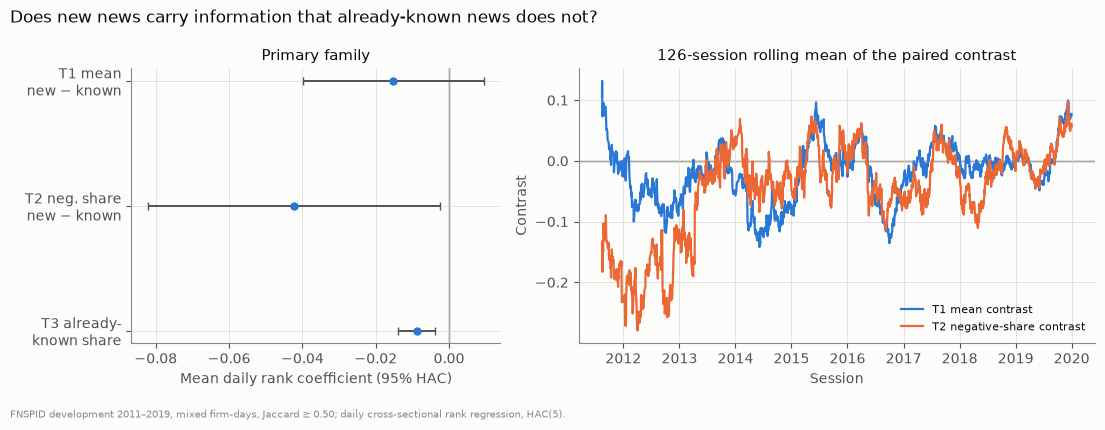

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0), gridspec_kw={"width_ratios": [1.0, 1.4]})

positions = np.arange(len(primary))
axes[0].errorbar(
    primary["estimate"],
    positions,
    xerr=[
        primary["estimate"] - primary["hac_ci_low"],
        primary["hac_ci_high"] - primary["estimate"],
    ],
    fmt="o",
    color=CATEGORICAL[0],
    ecolor=INK["secondary"],
    capsize=3,
    lw=1.4,
)
axes[0].set_yticks(positions)
axes[0].set_yticklabels(["T1 mean\nnew − known", "T2 neg. share\nnew − known", "T3 already-\nknown share"])
axes[0].invert_yaxis()
zero_line(axes[0], axis="x")
axes[0].set_xlabel("Mean daily rank coefficient (95% HAC)")
axes[0].set_title("Primary family")

daily_split = primary_frames["daily_split"]
rolling = (
    daily_split.set_index("session_date")[["contrast_mean", "contrast_negshare"]]
    .rolling(126, min_periods=63)
    .mean()
)
for column, colour, label in (
    ("contrast_mean", CATEGORICAL[0], "T1 mean contrast"),
    ("contrast_negshare", CATEGORICAL[1], "T2 negative-share contrast"),
):
    axes[1].plot(rolling.index, rolling[column], color=colour, lw=1.6, label=label)
zero_line(axes[1], axis="y")
axes[1].set_title("126-session rolling mean of the paired contrast")
axes[1].set_xlabel("Session")
axes[1].set_ylabel("Contrast")
axes[1].legend(frameon=False, fontsize=8)

fig.suptitle("Does new news carry information that already-known news does not?", ha="left", x=0.0)
annotate_source(
    fig,
    f"FNSPID development 2011–2019, mixed firm-days, Jaccard ≥ {PRIMARY_JACCARD_THRESHOLD:.2f}; "
    "daily cross-sectional rank regression, HAC(5).",
)
fig.tight_layout()
fig.savefig(OUTPUT / "primary_contrasts.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Declared secondary rows

Threshold sensitivity, the two marginal models, story-count strata, and per-year
contrasts. All were named in the frozen spec and none belongs to the BH family.

In [11]:
sensitivity = pd.concat(
    [run_family(threshold, label="sensitivity")[0] for threshold in SENSITIVITY_JACCARD_THRESHOLDS],
    ignore_index=True,
)
sensitivity = pd.concat([primary.drop(columns=["bh_reject", "bh_q", "supports_novelty_conditioning"]), sensitivity])
sensitivity = sensitivity.sort_values(["test", "threshold"]).reset_index(drop=True)
sensitivity.to_csv(OUTPUT / "threshold_sensitivity.csv", index=False)
display(sensitivity[["test", "threshold", "sessions", "estimate", "hac_ci_low", "hac_ci_high", "hac_p"]])

,test,threshold,sessions,estimate,hac_ci_low,hac_ci_high,hac_p
0,T1,0.400000,2136,-0.021208,-0.040637,-0.001779,0.032397
1,T1,0.500000,1920,-0.015195,-0.039802,0.009412,0.226172
2,T1,0.600000,1443,-0.011188,-0.045611,0.023235,0.524118
3,T1,0.800000,583,-0.009569,-0.082856,0.063718,0.798017
4,T2,0.400000,2136,-0.035604,-0.064026,-0.007183,0.014077
5,T2,0.500000,1920,-0.042235,-0.082070,-0.002401,0.037700
6,T2,0.600000,1443,-0.030980,-0.081564,0.019604,0.229997
7,T2,0.800000,583,-0.011530,-0.108797,0.085738,0.816283
8,T3,0.400000,2263,-0.008284,-0.012613,-0.003954,0.000177
9,T3,0.500000,2263,-0.008815,-0.013872,-0.003758,0.000634


In [12]:
primary_frame = build_test_frame(PRIMARY_JACCARD_THRESHOLD)
mixed_frame = primary_frame.loc[primary_frame["is_mixed_day"]]

marginal_rows = []
for label, regressors, column in (
    ("mean legs only", ["mean_new", "mean_known", "log1p_n"], ("beta_mean_new", "beta_mean_known")),
    (
        "negative-share legs only",
        ["negshare_new", "negshare_known", "log1p_n"],
        ("beta_negshare_new", "beta_negshare_known"),
    ),
):
    daily, _ = daily_rank_regression(
        mixed_frame,
        date_col="session_date",
        outcome_col=OUTCOME,
        regressor_cols=regressors,
        min_names=MIN_NAMES,
    )
    daily = contrast_series(daily, minuend=column[0], subtrahend=column[1], name="contrast")
    for statistic in (*column, "contrast"):
        summary = hac_mean_coefficient(daily, coefficient_col=statistic, hac_lags=HAC_LAGS)
        marginal_rows.append(
            {
                "model": label,
                "statistic": statistic,
                "sessions": int(summary["n_clusters"]),
                "estimate": float(summary["estimate"]),
                "ci_low": float(summary["ci_low"]),
                "ci_high": float(summary["ci_high"]),
                "p": float(summary["p_two_sided"]),
            }
        )
marginal = pd.DataFrame(marginal_rows)
marginal.to_csv(OUTPUT / "marginal_models.csv", index=False)
display(marginal)

,model,statistic,sessions,estimate,ci_low,ci_high,p
0,mean legs only,beta_mean_new,2041,0.005962,-0.004524,0.016448,0.265135
1,mean legs only,beta_mean_known,2041,0.003033,-0.008511,0.014578,0.606575
2,mean legs only,contrast,2041,0.002928,-0.013703,0.019560,0.730007
3,negative-share legs only,beta_negshare_new,1920,-0.023440,-0.041030,-0.005850,0.009007
4,negative-share legs only,beta_negshare_known,1920,0.002949,-0.019264,0.025162,0.794688
5,negative-share legs only,contrast,1920,-0.026389,-0.059145,0.006367,0.114335


The story-count strata matter most for **T3**. `known_share` is degenerate on a
single-story firm-day, where it can only be 0 or 1 and simply relabels that one
story, and the panel median is two stories. The standing rule is to condition on
`n` before reading a distribution-shape coefficient, so the declared strata are
applied to all three tests.

In [13]:
strata_rows = []
for minimum in (2, 5):
    mixed_subset = mixed_frame.loc[mixed_frame["n"] >= minimum]
    all_subset = primary_frame.loc[primary_frame["n"] >= minimum]

    split_daily_stratum, _ = daily_rank_regression(
        mixed_subset,
        date_col="session_date",
        outcome_col=OUTCOME,
        regressor_cols=SPLIT_REGRESSORS,
        min_names=MIN_NAMES,
    )
    split_daily_stratum = contrast_series(
        split_daily_stratum, minuend="beta_mean_new", subtrahend="beta_mean_known", name="contrast_mean"
    )
    split_daily_stratum = contrast_series(
        split_daily_stratum, minuend="beta_negshare_new", subtrahend="beta_negshare_known", name="contrast_negshare"
    )
    known_daily_stratum, _ = daily_rank_regression(
        all_subset,
        date_col="session_date",
        outcome_col=OUTCOME,
        regressor_cols=KNOWN_SHARE_REGRESSORS,
        min_names=MIN_NAMES,
    )

    for test_id, daily, column, firm_days in (
        ("T1", split_daily_stratum, "contrast_mean", len(mixed_subset)),
        ("T2", split_daily_stratum, "contrast_negshare", len(mixed_subset)),
        ("T3", known_daily_stratum, "beta_known_share", len(all_subset)),
    ):
        summary = hac_mean_coefficient(daily, coefficient_col=column, hac_lags=HAC_LAGS)
        strata_rows.append(
            {
                "stratum": f"n >= {minimum}",
                "test": test_id,
                "firm_days": int(firm_days),
                "sessions": int(summary["n_clusters"]),
                "estimate": float(summary["estimate"]),
                "ci_low": float(summary["ci_low"]),
                "ci_high": float(summary["ci_high"]),
                "p": float(summary["p_two_sided"]),
            }
        )
strata = pd.DataFrame(strata_rows).sort_values(["test", "stratum"]).reset_index(drop=True)
strata.to_csv(OUTPUT / "story_count_strata.csv", index=False)
display(strata)
display(
    Markdown(
        "Ordering disclosure: the first execution computed these strata for T1 and T2 only. "
        "T3 was added to the same declared secondary row after the primary table was visible, "
        "because a surviving `known_share` coefficient cannot be read without it. It remains a "
        "secondary diagnostic and does not enter the BH family."
    )
)

,stratum,test,firm_days,sessions,estimate,ci_low,ci_high,p
0,n >= 2,T1,53367,1920,-0.015195,-0.039802,0.009412,0.226172
1,n >= 5,T1,17859,615,-0.027215,-0.110251,0.055821,0.520634
2,n >= 2,T2,53367,1920,-0.042235,-0.082070,-0.002401,0.037700
3,n >= 5,T2,17859,615,-0.045596,-0.142112,0.050920,0.354487
4,n >= 2,T3,264683,2263,-0.008273,-0.014567,-0.001979,0.009987
5,n >= 5,T3,48862,1880,-0.009781,-0.025166,0.005605,0.212793


Ordering disclosure: the first execution computed these strata for T1 and T2 only. T3 was added to the same declared secondary row after the primary table was visible, because a surviving `known_share` coefficient cannot be read without it. It remains a secondary diagnostic and does not enter the BH family.

In [14]:
yearly = daily_split.assign(year=daily_split["session_date"].dt.year)
yearly_summary = (
    yearly.groupby("year")
    .agg(
        sessions=("contrast_mean", "size"),
        contrast_mean=("contrast_mean", "mean"),
        contrast_negshare=("contrast_negshare", "mean"),
    )
    .reset_index()
)
yearly_summary.to_csv(OUTPUT / "yearly_contrasts.csv", index=False)
display(yearly_summary)

,year,sessions,contrast_mean,contrast_negshare
0,2011,133,-0.009487,-0.219675
1,2012,191,-0.043334,-0.124699
2,2013,187,-0.059706,-0.047973
3,2014,190,-0.061834,-0.019120
4,2015,230,0.025660,0.000875
5,2016,249,-0.043725,-0.039455
6,2017,243,0.015515,-0.025229
7,2018,250,-0.007450,-0.020758
8,2019,247,0.025732,0.022224


## 7. Decision

In [15]:
survivors = primary.loc[primary["supports_novelty_conditioning"]]
decision_lines = [
    f"# Notebook 85 decision — {'supported' if len(survivors) else 'null'}",
    "",
    f"- Family: {len(primary)} declared tests, BH q=0.05. Survivors with the declared sign: "
    f"{len(survivors)} ({', '.join(survivors['test']) if len(survivors) else 'none'}).",
    f"- Block: FNSPID development only, through {DEVELOPMENT_END.date()}. The evaluation block was not loaded.",
    f"- Measurement: {measurement.loc[measurement['jaccard_threshold'] == PRIMARY_JACCARD_THRESHOLD, 'already_known_share'].item():.4f} "
    f"of development stories are already-known at Jaccard {PRIMARY_JACCARD_THRESHOLD:.2f}; "
    f"{primary_diagnostics['mixed_firm_days']:,} of {primary_diagnostics['all_firm_days']:,} firm-days are mixed.",
    "- The repetition screen is uncalibrated: Notebook 02's blinded 180-story audit has no human labels, "
    "so an unrecognised paraphrase counts as new and the already-known leg is a lower bound.",
    "- The contrast is identified on the busier end of the panel, because a mixed firm-day needs both legs present.",
    "",
    "## Primary rows",
    "",
    "```",
    primary[["test", "sessions", "estimate", "hac_ci_low", "hac_ci_high", "hac_p", "bh_q"]].to_string(index=False),
    "```",
    "",
    "## Declared story-count strata",
    "",
    "```",
    strata.to_string(index=False),
    "```",
]
decision = "\n".join(decision_lines) + "\n"
(OUTPUT / "decision.md").write_text(decision)
display(Markdown(decision))

# Notebook 85 decision — supported

- Family: 3 declared tests, BH q=0.05. Survivors with the declared sign: 1 (T3).
- Block: FNSPID development only, through 2019-12-31. The evaluation block was not loaded.
- Measurement: 0.0946 of development stories are already-known at Jaccard 0.50; 53,367 of 512,153 firm-days are mixed.
- The repetition screen is uncalibrated: Notebook 02's blinded 180-story audit has no human labels, so an unrecognised paraphrase counts as new and the already-known leg is a lower bound.
- The contrast is identified on the busier end of the panel, because a mixed firm-day needs both legs present.

## Primary rows

```
test  sessions  estimate  hac_ci_low  hac_ci_high    hac_p     bh_q
  T1      1920 -0.015195   -0.039802     0.009412 0.226172 0.226172
  T2      1920 -0.042235   -0.082070    -0.002401 0.037700 0.056549
  T3      2263 -0.008815   -0.013872    -0.003758 0.000634 0.001902
```

## Declared story-count strata

```
stratum test  firm_days  sessions  estimate    ci_low   ci_high        p
 n >= 2   T1      53367      1920 -0.015195 -0.039802  0.009412 0.226172
 n >= 5   T1      17859       615 -0.027215 -0.110251  0.055821 0.520634
 n >= 2   T2      53367      1920 -0.042235 -0.082070 -0.002401 0.037700
 n >= 5   T2      17859       615 -0.045596 -0.142112  0.050920 0.354487
 n >= 2   T3     264683      2263 -0.008273 -0.014567 -0.001979 0.009987
 n >= 5   T3      48862      1880 -0.009781 -0.025166  0.005605 0.212793
```
